In [1]:
from __future__ import annotations

import importlib
import json
import platform
import warnings
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "joblib": "joblib",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
OPTIONAL_PACKAGES = {
    "optuna": "optuna",
}

missing = []
for package_name, import_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing.append(package_name)

if missing:
    install_line = "%pip install -U " + " ".join(missing + list(OPTIONAL_PACKAGES))
    print("Missing required packages:", ", ".join(missing))
    print("Install them with:")
    print(install_line)
    raise ImportError("Install the missing packages, restart the kernel, and rerun the notebook.")

optional_missing = [package for package, import_name in OPTIONAL_PACKAGES.items() if importlib.util.find_spec(import_name) is None]
if optional_missing:
    print("Optional tuning packages missing:", ", ".join(optional_missing))
    print("Hyperparameter tuning will be unavailable until you install them:")
    print("%pip install -U " + " ".join(optional_missing))        

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("LightGBM:", lgb.__version__)

Python: 3.13.7
NumPy: 2.4.4
pandas: 3.0.2
LightGBM: 4.6.0


## 1) Configuration — Global Settings & Hyperparameters


In [3]:
RANDOM_STATE = 42
PHASE = "enrollment"

TEST_SIZE = 0.2
VALIDATION_SIZE = 0.20

RUN_TUNING = False
N_TRIALS = 50
CV_SPLITS = 3

RUN_PSEUDO_LABELING = True
PSEUDO_LABEL_THRESHOLD = 0.95

USE_CATBOOST_GPU = False
USE_LIGHTGBM_GPU = False
LIGHTGBM_GPU_PLATFORM_ID = 0
LIGHTGBM_GPU_DEVICE_ID = 0

SAVE_ARTIFACT = True

## 2) Data Loading — Reading & Preprocessing the Dataset


In [4]:
def find_project_paths() -> tuple[Path, Path, Path]:
    cwd = Path.cwd().resolve()
    candidate_paths = [
        cwd / "data" / "academic_success.csv",
        cwd / "research" / "data" / "academic_success.csv",
        cwd.parent / "research" / "data" / "academic_success.csv",
    ]
    for data_path in candidate_paths:
        if data_path.exists():
            research_dir = data_path.parents[1]
            project_root = data_path.parents[2]
            return project_root, research_dir, data_path
    raise FileNotFoundError("Could not find 'academic_success.csv' in expected locations.")

PROJECT_ROOT, RESEARCH_DIR, DATA_PATH = find_project_paths()
PICKLES_DIR = RESEARCH_DIR / "pickles"

RAW_COLUMN_RENAMES = {
    "Daytime/evening attendance\t": "Daytime/evening attendance",
    "Nacionality": "Nationality",
}

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()
df = df.rename(columns=RAW_COLUMN_RENAMES)

print("Data path:", DATA_PATH)
print ("Data shape:", df.shape)
display(df.head())

Data path: /home/fuder/Code/my_final_progect/research/data/academic_success.csv
Data shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3) EDA — Exploratory Data Analysis & Class Distribution


,Target,count,share
0,Graduate,2209,0.499322
1,Dropout,1421,0.321203
2,Enrolled,794,0.179476


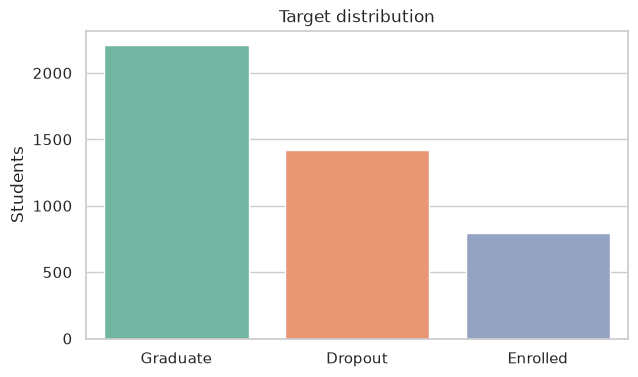

In [5]:
class_counts = df["Target"].value_counts().rename_axis("Target").reset_index(name="count")
class_counts["share"] = class_counts["count"] / class_counts["count"].sum()
display(class_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x="Target", y="count", ax=ax, palette="Set2", hue="Target", legend=False)
ax.set_title("Target distribution")
ax.set_xlabel("")
ax.set_ylabel("Students")
plt.show()

,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.613,13.188,95.00,125.0,133.10,140.00,190.00
Admission grade,4424.0,126.978,14.482,95.00,117.9,126.10,134.80,190.00
Age at enrollment,4424.0,23.265,7.588,17.00,19.0,20.00,25.00,70.00
Unemployment rate,4424.0,11.566,2.664,7.60,9.4,11.10,13.90,16.20
Inflation rate,4424.0,1.228,1.383,-0.80,0.3,1.40,2.60,3.70
GDP,4424.0,0.002,2.270,-4.06,-1.7,0.32,1.79,3.51


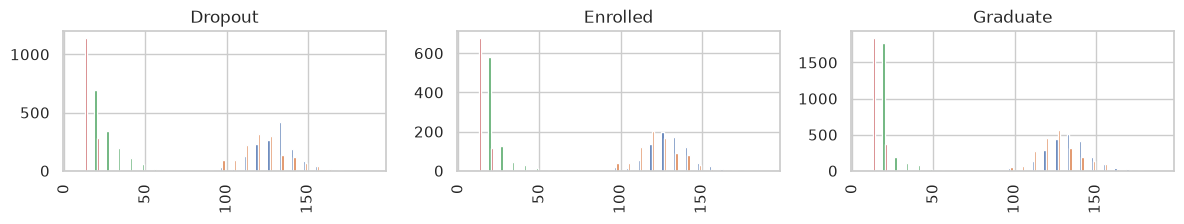

In [6]:
continuous_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
continuous_features = [col for col in continuous_features if col in df.columns]

display(df[continuous_features].describe().T.round(3))

if continuous_features:
    axes = df[continuous_features + ["Target"]].hist(
        by="Target",
        column=continuous_features[: min(len(continuous_features), 4)],
        figsize=(12, 8),
        bins=25,
        layout=(min(len(continuous_features), 4), 3),
    )
    plt.tight_layout()
    plt.show()

## 4) Feature Engineering — Selecting & Transforming Input Variables

In [7]:
LABEL_ORDER = ["Dropout", "Graduate"]
UNRESOLVED_LABEL = "Enrolled"
label_to_id = {label: idx for idx, label in enumerate(LABEL_ORDER)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

termilal_df = df[df["Target"].isin(LABEL_ORDER)].copy()
enrolled_df = df[df["Target"] == UNRESOLVED_LABEL].copy()

semester_1_features = [col for col in df.columns if col.startswith("Curricular units 1st sem")]
semester_2_features = [col for col in df.columns if col.startswith("Curricular units 2nd sem")]
base_features = [col for col in df.columns if col not in semester_1_features + semester_2_features + ["Target"]]

FEATURE_PHASES = {
    "enrollment": base_features,
    "semester_1": base_features + semester_1_features,
    "semester_2": base_features + semester_1_features + semester_2_features,
}

if PHASE not in FEATURE_PHASES:
    raise ValueError(f"Invalid phase '{PHASE}'. Valid options are: {', '.join(FEATURE_PHASES.keys())}.")

features = FEATURE_PHASES[PHASE]

categorical_candidates = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]

categorical_features = [col for col in categorical_candidates if col in features]
numeric_features = [col for col in features if col not in categorical_features]

print(f"Phase: {PHASE}")
print(f"Total features: {len(features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")
print("Excluded semester features:", sorted(set(semester_1_features + semester_2_features) - set(features)))

Phase: enrollment
Total features: 24
Categorical features: 18
Numeric features: 6
Excluded semester features: ['Curricular units 1st sem (approved)', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']


In [8]:
X_terminal = termilal_df[features].copy()
y_terminal = termilal_df["Target"].map(label_to_id).astype(int)
X_enrolled = enrolled_df[features].copy()

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_terminal, y_terminal, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_terminal)

valid_fraction_of_train_valid = VALIDATION_SIZE / (1 - TEST_SIZE)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_fraction_of_train_valid, random_state=RANDOM_STATE, stratify=y_train_valid)

splt_counts = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "valid": y_valid.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).rename(index=id_to_label)
display(splt_counts)

print("Unlabeled enrolled rows available for pseudo-labeling:", len(X_enrolled))

,train,valid,test
Target,,,
Dropout,853,284,284
Graduate,1325,442,442


Unlabeled enrolled rows available for pseudo-labeling: 794


In [9]:
def make_catboost_frame(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    for col in categorical_features:
        X_out[col] = X_out[col].astype("category")
    return X_out

def make_lightgbm_frame(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    for col in categorical_features:
        X_out[col] = X_out[col].astype("category")
    return X_out

X_train_cb = make_catboost_frame(X_train)
X_valid_cb = make_catboost_frame(X_valid)
X_test_cb = make_catboost_frame(X_test)
X_enrolled_cb = make_catboost_frame(X_enrolled)

X_train_lgb = make_lightgbm_frame(X_train)
X_valid_lgb = make_lightgbm_frame(X_valid)
X_test_lgb = make_lightgbm_frame(X_test)
X_enrolled_lgb = make_lightgbm_frame(X_enrolled)

## 5) Metrics — Evaluation Functions & Scoring Utilities


In [10]:
def align_proba(model, X_model: pd.DataFrame, n_classes: int = len(LABEL_ORDER)) -> np.ndarray:
    proba = np.asarray(model.predict_proba(X_model))
    classes = np.asarray(model.classes_, dtype=int)
    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
    for source_idx, class_id in enumerate(classes):
        aligned[:, class_id] = proba[:, source_idx]
    return aligned

def weighted_average_proba(probas: list[np.ndarray], weights: list[float] | np.ndarray) -> np.ndarray:
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    stacked = np.stack(probas, axis=0)
    return np.tensordot(weights, stacked, axes=([0], [0]))
    
def evaluate_predictions(
    name: str,
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray, 
    y_proba: np.ndarray | None = None,
    show_report: bool = True,
) -> dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_dropout": f1_score(y_true, y_pred, pos_label=label_to_id["Dropout"]),
        "f1_graduate": f1_score(y_true, y_pred, pos_label=label_to_id["Graduate"]),
        "precision_graduate": precision_score(y_true, y_pred, pos_label=label_to_id["Graduate"]),
        "recall_graduate": recall_score(y_true, y_pred, pos_label=label_to_id["Graduate"]),
    }
    if y_proba is not None:
        metrics["log_loss"] = log_loss(y_true, y_proba, labels=list(range(len(LABEL_ORDER))))
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba[:, label_to_id["Graduate"]])

    print(f"{name} metrics")
    display(pd.Series(metrics).to_frame("score").T.round(4))

    if show_report:
        print(classification_report(y_true, y_pred, target_names=LABEL_ORDER, digits=4))
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABEL_ORDER))))
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
        ax.set_title(f"{name} confusion matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.show()

    return metrics

def evaluate_model(name: str, model, X_model: pd.DataFrame, y_true: pd.Series | np.ndarray, show_report: bool = True) -> dict[str, float]:
    y_pred = np.asarray(model.predict(X_model)).reshape(-1).astype(int)
    y_proba = align_proba(model, X_model)
    return evaluate_predictions(name, y_true, y_pred, y_proba, show_report=show_report)

def select_blend_weights(cat_proba: np.ndarray, lgb_proba: np.ndarray, y_true: pd.Series | np.ndarray) -> tuple[float, float, pd.DataFrame]:
    weight_rows = []
    for cat_weight in np.linspace(0, 1, 21):
        weights = [cat_weight, 1 - cat_weight]
        blended = weighted_average_proba([cat_proba, lgb_proba], weights)
        pred = blended.argmax(axis=1)
        weight_rows.append({
            "catboost_weight": cat_weight,
            "lightgbm_weight": 1 - cat_weight,
            "f1_macro": f1_score(y_true, pred, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "roc_auc": roc_auc_score(y_true, blended[:, label_to_id["Graduate"]]),
        })
    weight_search = pd.DataFrame(weight_rows).sort_values(["f1_macro", "balanced_accuracy"], ascending=False)
    best = weight_search.iloc[0]
    return float(best["catboost_weight"]), float(best["lightgbm_weight"]), weight_search
    


## 6) Hyperparameter Tuning — Optuna-based Optimization


In [11]:
catboost_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 1000,
    "learning_rate": 0.035,
    "depth": 5,
    "l2_leaf_reg": 6,
    "random_strength": 1.0,
    "auto_class_weights": "Balanced",
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 0.5,
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "verbose": False,
}

if USE_CATBOOST_GPU:
    catboost_params["task_type"] = "GPU"
    catboost_params["devices"] = "0"

lightgbm_params = {
    "objective": "binary",
    "n_estimators": 900,
    "learning_rate": 0.035,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.85,
    "subsample_freq": 1,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 2.0,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

if USE_LIGHTGBM_GPU:
    lightgbm_params.update({
        "device_type": "gpu",
        "gpu_platform_id": LIGHTGBM_GPU_PLATFORM_ID,
        "gpu_device_id": LIGHTGBM_GPU_DEVICE_ID,
        "max_bin": 63,
    })

def tune_catboost(X_all: pd.DataFrame, y_all: pd.Series) -> dict:
    import optuna

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial: optuna.Trial) -> float:
        params = {
            **catboost_params,
            "iterations": trial.suggest_int("iterations", 500, 1800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "depth": trial.suggest_int("depth", 3, 8),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 20.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.0, 4.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        }
        scores = []
        for train_idx, valid_idx in cv.split(X_all, y_all):
            X_fold_train = make_catboost_frame(X_all.iloc[train_idx])
            X_fold_valid = make_catboost_frame(X_all.iloc[valid_idx])
            y_fold_train = y_all.iloc[train_idx]
            y_fold_valid = y_all.iloc[valid_idx]

            model = CatBoostClassifier(**params)
            model.fit(X_fold_train, y_fold_train, cat_features=categorical_features, eval_set=(X_fold_valid, y_fold_valid), early_stopping_rounds=100, verbose=False)
            pred = np.asarray(model.predict(X_fold_valid)).reshape(-1).astype(int)
            scores.append(f1_score(y_fold_valid, pred, average="macro"))
        return float(np.mean(scores))
        
    study = optuna.create_study(direction="maximize", study_name=f"catboost_{PHASE}_macro_f1")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print("Best CatBoost macro F1:", study.best_value)
    print("Best CatBoost params:", study.best_params)
    return study.best_params

def tune_lightgbm(X_all: pd.DataFrame, y_all: pd.Series) -> dict:
    import optuna

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial: optuna.Trial) -> float:
        params = {
            **lightgbm_params,
            "n_estimators": trial.suggest_int("n_estimators", 400, 1800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 95),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),
        }
        scores = []
        for train_idx, valid_idx in cv.split(X_all, y_all):
            X_fold_train = make_lightgbm_frame(X_all.iloc[train_idx])
            X_fold_valid = make_lightgbm_frame(X_all.iloc[valid_idx])
            y_fold_train = y_all.iloc[train_idx]
            y_fold_valid = y_all.iloc[valid_idx]

            model = LGBMClassifier(**params)
            model.fit(
                X_fold_train,
                y_fold_train,
                eval_set=[(X_fold_valid, y_fold_valid)],
                eval_metric="binary_logloss",
                categorical_feature=categorical_features,
                callbacks=[lgb.early_stopping(100, verbose=False)],
            )
            pred = np.asarray(model.predict(X_fold_valid)).reshape(-1).astype(int)
            scores.append(f1_score(y_fold_valid, pred, average="macro"))
        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize", study_name=f"lightgbm_{PHASE}_macro_f1")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print("Best LightGBM macro F1:", study.best_value)
    print("Best LightGBM params:", study.best_params)
    return study.best_params


if RUN_TUNING:
    if importlib.util.find_spec("optuna") is None:
        raise ImportError("RUN_TUNING=True requires optuna. Install with `%pip install -U optuna`.")
    tuned_catboost_params = tune_catboost(X_train_valid, y_train_valid)
    tuned_lightgbm_params = tune_lightgbm(X_train_valid, y_train_valid)
    catboost_params.update(tuned_catboost_params)
    lightgbm_params.update(tuned_lightgbm_params)
else:
    print("RUN_TUNING is False; using hand-set, conservative defaults.")

RUN_TUNING is False; using hand-set, conservative defaults.


## 7) Pseudo-Labeling — Semi-Supervised Data Augmentation

### The initial model is trained on true Graduate and Dropout outcomes. Predictions are then made on Enrolled students, and high-confidence results are added to the final training set. Validation and test sets use only true outcomes.

In [12]:
def fit_catboost(X_fit: pd.DataFrame, y_fit: pd.Series, X_eval: pd.DataFrame, y_eval: pd.Series) -> CatBoostClassifier:
    model = CatBoostClassifier(**catboost_params)
    model.fit(X_fit, y_fit, cat_features=categorical_features, eval_set=(X_eval, y_eval), early_stopping_rounds=120, verbose=False)
    return model

def fit_lightgbm(X_fit: pd.DataFrame, y_fit: pd.Series, X_eval: pd.DataFrame, y_eval: pd.Series) -> LGBMClassifier:
    model = LGBMClassifier(**lightgbm_params)
    model.fit(X_fit, y_fit, eval_set=[(X_eval, y_eval)], eval_metric="binary_logloss", categorical_feature=categorical_features, callbacks=[lgb.early_stopping(120, verbose=False), lgb.log_evaluation(100)])
    return model

pseudo_summary = {
    "enabled": RUN_PSEUDO_LABELING,
    "threshold": PSEUDO_LABEL_THRESHOLD,
    "unresolved_label": UNRESOLVED_LABEL,
    "unresolved_rows" : len(X_enrolled),
    "selected_rows": 0,
    "selected_dropout": 0,
    "selected_graduate": 0,
}

X_train_aug = X_train.copy()
y_train_aug = y_train.copy()

if RUN_PSEUDO_LABELING and len(X_enrolled) > 0:
    cat_model = fit_catboost(X_train_cb, y_train, X_valid_cb, y_valid)
    lgb_model = fit_lightgbm(X_train_lgb, y_train, X_valid_lgb, y_valid)

    cat_proba_valid = align_proba(cat_model, X_valid_cb)
    lgb_proba_valid = align_proba(lgb_model, X_valid_lgb)
    cat_weight, lgb_weight, weight_search = select_blend_weights(cat_proba_valid, lgb_proba_valid, y_valid)

    cat_proba_enrolled = align_proba(cat_model, make_catboost_frame(X_enrolled))
    lgb_proba_enrolled = align_proba(lgb_model, make_lightgbm_frame(X_enrolled))

    print(f"Selected blend weights - CatBoost: {cat_weight:.2f}, LightGBM: {lgb_weight:.2f}")
    display(weight_search.head(10).round(4))

    cat_enrolled_proba = align_proba(cat_model, X_enrolled_cb)

    blended_proba_enrolled = weighted_average_proba([cat_proba_enrolled, lgb_proba_enrolled], [cat_weight, lgb_weight])
    max_proba = blended_proba_enrolled.max(axis=1)
    pseudo_labels = blended_proba_enrolled.argmax(axis=1)

    selected_mask = max_proba >= PSEUDO_LABEL_THRESHOLD
    selected_indices = np.where(selected_mask)[0]
    selected_pseudo_labels = pseudo_labels[selected_mask]

    X_selected = X_enrolled.iloc[selected_indices]
    y_selected = pd.Series(selected_pseudo_labels).map(id_to_label).map(label_to_id).astype(int)

    X_train_aug = pd.concat([X_train_aug, X_selected], axis=0).reset_index(drop=True)
    y_train_aug = pd.concat([y_train_aug, y_selected], axis=0).reset_index(drop=True)

    pseudo_summary.update({
        "selected_rows": len(X_selected),
        "selected_dropout": (y_selected == label_to_id["Dropout"]).sum(),
        "selected_graduate": (y_selected == label_to_id["Graduate"]).sum(),
        "cat_weight": cat_weight,
        "lightgbm_weight": lgb_weight,
    })

[100]	valid_0's binary_logloss: 0.444605
[200]	valid_0's binary_logloss: 0.43321
[300]	valid_0's binary_logloss: 0.438754
Selected blend weights - CatBoost: 0.05, LightGBM: 0.95


,catboost_weight,lightgbm_weight,f1_macro,balanced_accuracy,roc_auc
1,0.05,0.95,0.7931,0.7929,0.8709
4,0.20,0.80,0.7915,0.7912,0.8719
14,0.70,0.30,0.7915,0.7912,0.8727
19,0.95,0.05,0.7915,0.7912,0.8703
20,1.00,0.00,0.7915,0.7912,0.8696
2,0.10,0.90,0.7905,0.7907,0.8713
15,0.75,0.25,0.7905,0.7907,0.8722
18,0.90,0.10,0.7905,0.7907,0.8708
3,0.15,0.85,0.7902,0.7900,0.8716
13,0.65,0.35,0.7902,0.7900,0.8728


## 7) CatBoost Training — Gradient Boosting on Categorical Features


0:	test: 0.7352304	best: 0.7352304 (0)	total: 1.38ms	remaining: 1.38s


100:	test: 0.8563189	best: 0.8563189 (100)	total: 160ms	remaining: 1.42s


200:	test: 0.8623893	best: 0.8627079 (199)	total: 328ms	remaining: 1.3s


300:	test: 0.8675754	best: 0.8683322 (284)	total: 502ms	remaining: 1.16s


400:	test: 0.8681728	best: 0.8687384 (357)	total: 678ms	remaining: 1.01s


500:	test: 0.8693041	best: 0.8695829 (497)	total: 849ms	remaining: 845ms


600:	test: 0.8667309	best: 0.8695829 (497)	total: 1.02s	remaining: 678ms


Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.8695828819
bestIteration = 497

Shrink model to first 498 iterations.
CatBoost validation metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
score,0.8017,0.7912,0.7915,0.8015,0.7456,0.8375,0.8356,0.8394,0.4388,0.8696


              precision    recall  f1-score   support

     Dropout     0.7482    0.7430    0.7456       284
    Graduate     0.8356    0.8394    0.8375       442

    accuracy                         0.8017       726
   macro avg     0.7919    0.7912    0.7915       726
weighted avg     0.8014    0.8017    0.8015       726



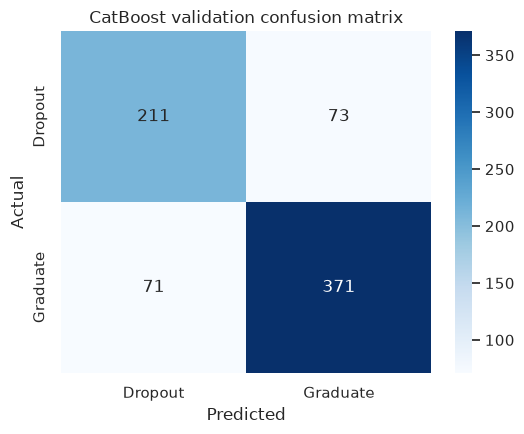

In [13]:
cat_model = CatBoostClassifier(**catboost_params)
cat_model.fit(X_train_cb, y_train, cat_features=categorical_features, eval_set=(X_valid_cb, y_valid), early_stopping_rounds=120, verbose=100)
cat_valid_metrics = evaluate_model("CatBoost validation", cat_model, X_valid_cb, y_valid, show_report=True)

Training until validation scores don't improve for 120 rounds
[100]	valid_0's binary_logloss: 0.444605
[200]	valid_0's binary_logloss: 0.43321


[300]	valid_0's binary_logloss: 0.438754
Early stopping, best iteration is:
[193]	valid_0's binary_logloss: 0.433095
LightGBM validation metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
score,0.7989,0.7876,0.7884,0.7986,0.7411,0.8356,0.8318,0.8394,0.4331,0.8703


              precision    recall  f1-score   support

     Dropout     0.7464    0.7359    0.7411       284
    Graduate     0.8318    0.8394    0.8356       442

    accuracy                         0.7989       726
   macro avg     0.7891    0.7876    0.7884       726
weighted avg     0.7984    0.7989    0.7986       726



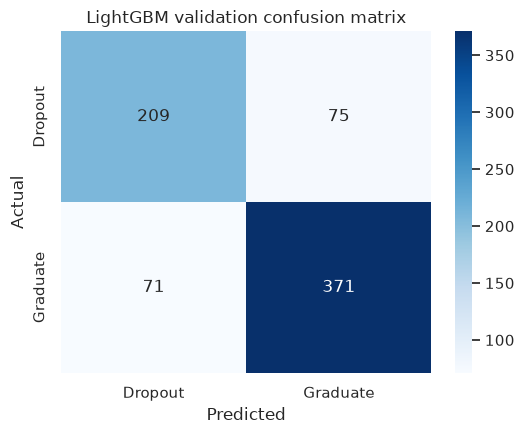

In [14]:
lgb_model = LGBMClassifier(**lightgbm_params)
lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    eval_metric="binary_logloss",
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(120, verbose=100), lgb.log_evaluation(100)],
)
lgb_valid_metrics = evaluate_model("LightGBM validation", lgb_model, X_valid_lgb, y_valid, show_report=True)

## 8) Ensemble — Soft Voting with CatBoost & LightGBM


,catboost_weight,lightgbm_weight,f1_macro,balanced_accuracy
1,0.05,0.95,0.7931,0.7929
20,1.00,0.00,0.7915,0.7912
4,0.20,0.80,0.7915,0.7912
19,0.95,0.05,0.7915,0.7912
14,0.70,0.30,0.7915,0.7912
2,0.10,0.90,0.7905,0.7907
18,0.90,0.10,0.7905,0.7907
15,0.75,0.25,0.7905,0.7907
13,0.65,0.35,0.7902,0.7900
3,0.15,0.85,0.7902,0.7900


Soft vote validation metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
score,0.803,0.7929,0.7931,0.803,0.7478,0.8384,0.8375,0.8394,0.4325,0.8709


              precision    recall  f1-score   support

     Dropout     0.7491    0.7465    0.7478       284
    Graduate     0.8375    0.8394    0.8384       442

    accuracy                         0.8030       726
   macro avg     0.7933    0.7929    0.7931       726
weighted avg     0.8029    0.8030    0.8030       726



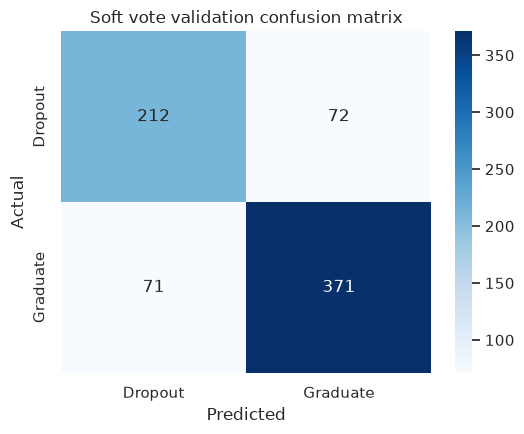

Selected weights: CatBoost=0.05, LightGBM=0.95


In [15]:
def weighted_average_proba(probas: list[np.ndarray], weights: list[float] | np.ndarray) -> np.ndarray:
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    stacked = np.stack(probas, axis=0)
    return np.tensordot(weights, stacked, axes=(0, 0))


cat_valid_proba = align_proba(cat_model, X_valid_cb)
lgb_valid_proba = align_proba(lgb_model, X_valid_lgb)

weight_rows = []
for cat_weight in np.linspace(0.0, 1.0, 21):
    weights = [cat_weight, 1.0 - cat_weight]
    blended = weighted_average_proba([cat_valid_proba, lgb_valid_proba], weights)
    pred = blended.argmax(axis=1)
    weight_rows.append({
        "catboost_weight": cat_weight,
        "lightgbm_weight": 1.0 - cat_weight,
        "f1_macro": f1_score(y_valid, pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_valid, pred),
    })

weight_search = pd.DataFrame(weight_rows).sort_values("f1_macro", ascending=False)
display(weight_search.head(10).round(4))

best_cat_weight = float(weight_search.iloc[0]["catboost_weight"])
best_lgb_weight = 1.0 - best_cat_weight
ensemble_valid_proba = weighted_average_proba([cat_valid_proba, lgb_valid_proba], [best_cat_weight, best_lgb_weight])
ensemble_valid_pred = ensemble_valid_proba.argmax(axis=1)
ensemble_valid_metrics = evaluate_predictions(
    "Soft vote validation",
    y_valid,
    ensemble_valid_pred,
    ensemble_valid_proba,
    show_report=True,
)
print(f"Selected weights: CatBoost={best_cat_weight:.2f}, LightGBM={best_lgb_weight:.2f}")


## 9) Feature Importance — Model Interpretability & SHAP Analysis

,catboost_importance,lightgbm_importance
Tuition fees up to date,0.1862,0.0177
Course,0.1164,0.0499
Scholarship holder,0.0766,0.0264
Application mode,0.0649,0.0156
Age at enrollment,0.0647,0.1219
Previous qualification (grade),0.0609,0.1806
Admission grade,0.0508,0.2345
Father's occupation,0.0462,0.0283
Mother's occupation,0.0426,0.0195
Father's qualification,0.0393,0.0134


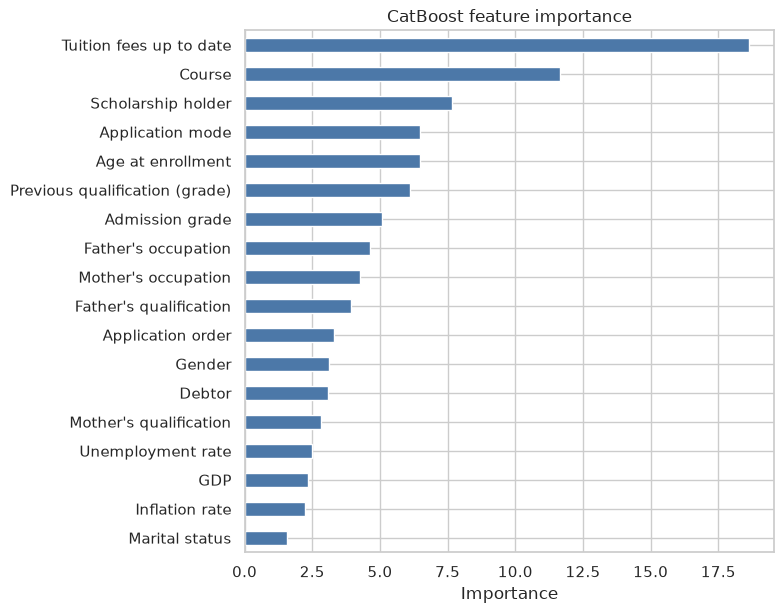

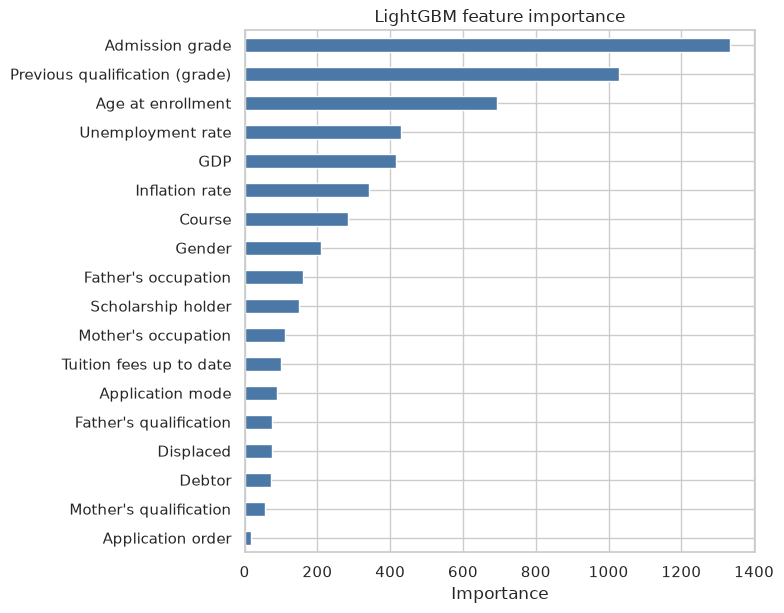

In [16]:
def plot_importance(importances: pd.Series, title: str, top_n: int = 18) -> None:
    top = importances.sort_values(ascending=False).head(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(top))))
    top.plot(kind="barh", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

cat_importance = pd.Series(cat_model.get_feature_importance(), index=features, name="catboost_importance")
lgb_importance = pd.Series(lgb_model.feature_importances_, index=features, name="lightgbm_importance")

importance_table = pd.concat([
    cat_importance / max(cat_importance.sum(), 1e-12),
    lgb_importance / max(lgb_importance.sum(), 1e-12),
], axis=1).sort_values("catboost_importance", ascending=False)

display(importance_table.head(25).round(4))
plot_importance(cat_importance, "CatBoost feature importance")
plot_importance(lgb_importance, "LightGBM feature importance")

## 10) Final Test — Evaluation on Held-out Test Set


CatBoost test metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
score,0.781,0.7698,0.77,0.7809,0.7196,0.8203,0.8194,0.8213,0.4554,0.8576


              precision    recall  f1-score   support

     Dropout     0.7208    0.7183    0.7196       284
    Graduate     0.8194    0.8213    0.8203       442

    accuracy                         0.7810       726
   macro avg     0.7701    0.7698    0.7700       726
weighted avg     0.7809    0.7810    0.7809       726



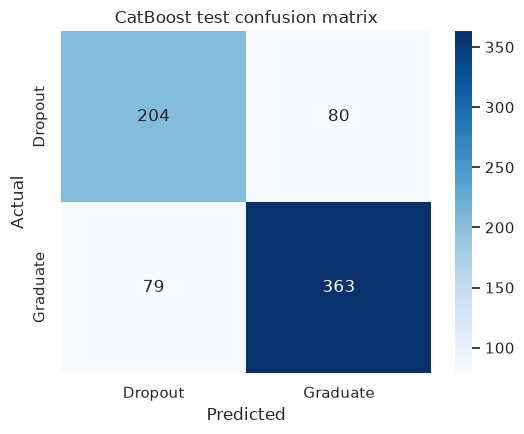

LightGBM test metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
score,0.7837,0.7689,0.771,0.7828,0.7171,0.825,0.8132,0.8371,0.447,0.8599


              precision    recall  f1-score   support

     Dropout     0.7343    0.7007    0.7171       284
    Graduate     0.8132    0.8371    0.8250       442

    accuracy                         0.7837       726
   macro avg     0.7738    0.7689    0.7710       726
weighted avg     0.7823    0.7837    0.7828       726



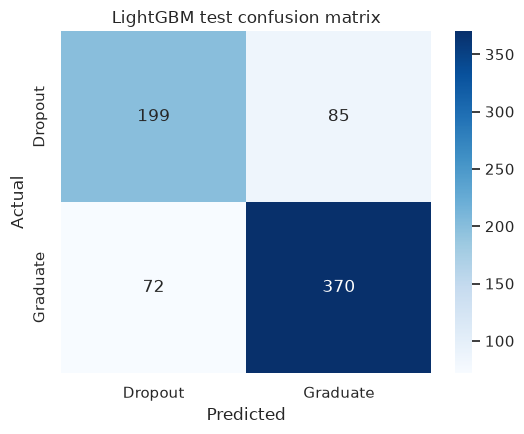

Soft vote test metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
score,0.7865,0.7724,0.7743,0.7857,0.7217,0.8268,0.8168,0.8371,0.4464,0.8606


              precision    recall  f1-score   support

     Dropout     0.7363    0.7077    0.7217       284
    Graduate     0.8168    0.8371    0.8268       442

    accuracy                         0.7865       726
   macro avg     0.7765    0.7724    0.7743       726
weighted avg     0.7853    0.7865    0.7857       726



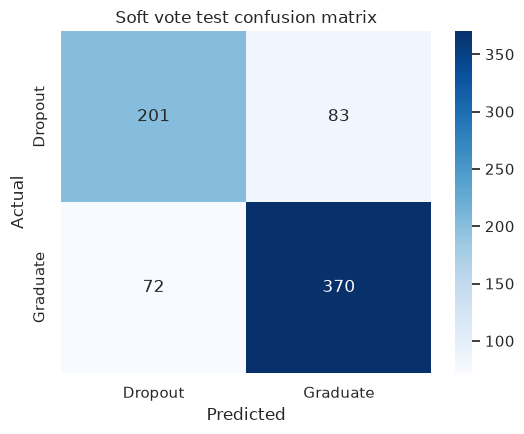

,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_dropout,f1_graduate,precision_graduate,recall_graduate,log_loss,roc_auc
Soft vote valid,0.8030,0.7929,0.7931,0.8030,0.7478,0.8384,0.8375,0.8394,0.4325,0.8709
CatBoost valid,0.8017,0.7912,0.7915,0.8015,0.7456,0.8375,0.8356,0.8394,0.4388,0.8696
LightGBM valid,0.7989,0.7876,0.7884,0.7986,0.7411,0.8356,0.8318,0.8394,0.4331,0.8703
Soft vote test,0.7865,0.7724,0.7743,0.7857,0.7217,0.8268,0.8168,0.8371,0.4464,0.8606
LightGBM test,0.7837,0.7689,0.7710,0.7828,0.7171,0.8250,0.8132,0.8371,0.4470,0.8599
CatBoost test,0.7810,0.7698,0.7700,0.7809,0.7196,0.8203,0.8194,0.8213,0.4554,0.8576


In [17]:
cat_test_metrics = evaluate_model("CatBoost test", cat_model, X_test_cb, y_test, show_report=True)
lgb_test_metrics = evaluate_model("LightGBM test", lgb_model, X_test_lgb, y_test, show_report=True)

cat_test_proba = align_proba(cat_model, X_test_cb)
lgb_test_proba = align_proba(lgb_model, X_test_lgb)
ensemble_test_proba = weighted_average_proba([cat_test_proba, lgb_test_proba], [best_cat_weight, best_lgb_weight])
ensemble_test_pred = ensemble_test_proba.argmax(axis=1)
ensemble_test_metrics = evaluate_predictions(
    "Soft vote test",
    y_test,
    ensemble_test_pred,
    ensemble_test_proba,
    show_report=True,
)

metrics_table = pd.DataFrame({
    "CatBoost valid": cat_valid_metrics,
    "LightGBM valid": lgb_valid_metrics,
    "Soft vote valid": ensemble_valid_metrics,
    "CatBoost test": cat_test_metrics,
    "LightGBM test": lgb_test_metrics,
    "Soft vote test": ensemble_test_metrics,
}).T

display(metrics_table.round(4).sort_values("f1_macro", ascending=False))


## 11) Model Saving — Serializing the Final Artifact


In [18]:
bundle = {
    "phase": PHASE,
    "features": features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "label_order": LABEL_ORDER,
    "label_to_id": label_to_id,
    "id_to_label": id_to_label,
    "column_renames": RAW_COLUMN_RENAMES,
    "problem_type": "binary_terminal_outcome_with_pseudo_labeling",
    "unresolved_label": UNRESOLVED_LABEL,
    "pseudo_labeling": pseudo_summary,
    "models": {
        "catboost": cat_model,
        "lightgbm": lgb_model,
    },
    "ensemble": {
        "kind": "weighted_probability_average",
        "catboost_weight": best_cat_weight,
        "lightgbm_weight": best_lgb_weight,
    },
    "metrics": metrics_table.to_dict(orient="index"),
    "config": {
        "random_state": RANDOM_STATE,
        "phase": PHASE,
        "run_tuning": RUN_TUNING,
        "use_catboost_gpu": USE_CATBOOST_GPU,
        "use_lightgbm_gpu": USE_LIGHTGBM_GPU,
    },
}

if SAVE_ARTIFACT:
    PICKLES_DIR.mkdir(parents=True, exist_ok=True)
    artifact_path = PICKLES_DIR / "academic_success_enrollment_catboost_lightgbm_bundle.pkl"
    joblib.dump(bundle, artifact_path)
    print(f"Saved model bundle to {artifact_path}")
else:
    print("SAVE_ARTIFACT is False; not saving model bundle.")

Saved model bundle to /home/fuder/Code/my_final_progect/research/pickles/academic_success_enrollment_catboost_lightgbm_bundle.pkl
